<h2 style="color:green" align="center">Implement Gradient Descent For Neural Network (or Logistic Regression)</h2>

<h4 style="color:blue">Predicting if a person would buy life insurnace based on his age using logistic regression</h4>

Above is a binary logistic regression problem as there are only two possible outcomes (i.e. if person buys insurance or he/she doesn't). 

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


**Split train and test set**

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['age','affordibility']],df.bought_insurance,test_size=0.2, random_state=25)

**Preprocessing: Scale the data so that both age and affordibility are in same scaling range**

In [4]:
X_train_scaled = X_train.copy()
X_train_scaled['age'] = X_train_scaled['age'] / 100

X_test_scaled = X_test.copy()
X_test_scaled['age'] = X_test_scaled['age'] / 100

**Model Building: First build a model in keras/tensorflow and see what weights and bias values it comes up with. We will than try to reproduce same weights and bias in our plain python implementation of gradient descent. Below is the architecture of our simple neural network**

<img src="nn.png" height=800 width=800/>

In [5]:
 # Here kernel_initializer='ones' means initialize weight to 1
# bias_initializer='zeros' means initialize bias to 0
    
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(2,), activation='sigmoid', kernel_initializer='ones', bias_initializer='zeros')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=5000)

Epoch 1/5000
1/1 [==============================] - 0s 458ms/step - loss: 0.7113 - accuracy: 0.5000
Epoch 2/5000
1/1 [==============================] - 0s 6ms/step - loss: 0.7110 - accuracy: 0.5000
Epoch 3/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.7106 - accuracy: 0.5000
Epoch 4/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.7102 - accuracy: 0.5000
Epoch 5/5000
1/1 [==============================] - 0s 4ms/step - loss: 0.7098 - accuracy: 0.5000
Epoch 6/5000
1/1 [==============================] - 0s 967us/step - loss: 0.7094 - accuracy: 0.5000
Epoch 7/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.7091 - accuracy: 0.5000
Epoch 8/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.7087 - accuracy: 0.5000
Epoch 9/5000
1/1 [==============================] - 0s 7ms/step - loss: 0.7083 - accuracy: 0.5000
Epoch 10/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.7079 - accuracy: 0.5000
Epoch 11/5000
1

1/1 [==============================] - 0s 2ms/step - loss: 0.6626 - accuracy: 0.5000
Epoch 166/5000
1/1 [==============================] - 0s 1000us/step - loss: 0.6624 - accuracy: 0.5000
Epoch 167/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6622 - accuracy: 0.5000
Epoch 168/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6620 - accuracy: 0.5000
Epoch 169/5000
1/1 [==============================] - 0s 5ms/step - loss: 0.6617 - accuracy: 0.5000
Epoch 170/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6615 - accuracy: 0.5000
Epoch 171/5000
1/1 [==============================] - 0s 1000us/step - loss: 0.6613 - accuracy: 0.5000
Epoch 172/5000
1/1 [==============================] - 0s 3ms/step - loss: 0.6611 - accuracy: 0.5000
Epoch 173/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6609 - accuracy: 0.5455
Epoch 174/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6607 - accuracy: 0.5455
Epoch 175

Epoch 328/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.6379 - accuracy: 0.6364
Epoch 329/5000
1/1 [==============================] - 0s 3ms/step - loss: 0.6378 - accuracy: 0.6364
Epoch 330/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6377 - accuracy: 0.6364
Epoch 331/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6376 - accuracy: 0.6364
Epoch 332/5000
1/1 [==============================] - 0s 5ms/step - loss: 0.6375 - accuracy: 0.6364
Epoch 333/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6374 - accuracy: 0.6364
Epoch 334/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.6373 - accuracy: 0.6364
Epoch 335/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6372 - accuracy: 0.6364
Epoch 336/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6371 - accuracy: 0.6364
Epoch 337/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6370 - accuracy: 0.6364


Epoch 491/5000
1/1 [==============================] - 0s 3ms/step - loss: 0.6259 - accuracy: 0.6364
Epoch 492/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6258 - accuracy: 0.6364
Epoch 493/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6257 - accuracy: 0.6364
Epoch 494/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6257 - accuracy: 0.6364
Epoch 495/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6256 - accuracy: 0.6364
Epoch 496/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.6256 - accuracy: 0.6364
Epoch 497/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6255 - accuracy: 0.6364
Epoch 498/5000
1/1 [==============================] - 0s 966us/step - loss: 0.6255 - accuracy: 0.6364
Epoch 499/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6254 - accuracy: 0.6364
Epoch 500/5000
1/1 [==============================] - 0s 4ms/step - loss: 0.6253 - accuracy: 0.636

1/1 [==============================] - 0s 2ms/step - loss: 0.6176 - accuracy: 0.7273
Epoch 654/5000
1/1 [==============================] - 0s 3ms/step - loss: 0.6176 - accuracy: 0.7273
Epoch 655/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.6175 - accuracy: 0.7273
Epoch 656/5000
1/1 [==============================] - 0s 5ms/step - loss: 0.6175 - accuracy: 0.7273
Epoch 657/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6174 - accuracy: 0.7273
Epoch 658/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6174 - accuracy: 0.7273
Epoch 659/5000
1/1 [==============================] - 0s 5ms/step - loss: 0.6173 - accuracy: 0.7273
Epoch 660/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6173 - accuracy: 0.7273
Epoch 661/5000
1/1 [==============================] - 0s 6ms/step - loss: 0.6172 - accuracy: 0.7273
Epoch 662/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.6172 - accuracy: 0.7273
Epoch 663/5000


...

1/1 [==============================] - 0s 2ms/step - loss: 0.4742 - accuracy: 0.9091
Epoch 4458/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4742 - accuracy: 0.9091
Epoch 4459/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4741 - accuracy: 0.9091
Epoch 4460/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4741 - accuracy: 0.9091
Epoch 4461/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4741 - accuracy: 0.9091
Epoch 4462/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4741 - accuracy: 0.9091
Epoch 4463/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4740 - accuracy: 0.9091
Epoch 4464/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4740 - accuracy: 0.9091
Epoch 4465/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4740 - accuracy: 0.9091
Epoch 4466/5000
1/1 [==============================] - 0s 974us/step - loss: 0.4740 - accuracy: 0.9091
Epoc

1/1 [==============================] - 0s 3ms/step - loss: 0.4707 - accuracy: 0.9091
Epoch 4619/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4707 - accuracy: 0.9091
Epoch 4620/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4707 - accuracy: 0.9091
Epoch 4621/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4706 - accuracy: 0.9091
Epoch 4622/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4706 - accuracy: 0.9091
Epoch 4623/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4706 - accuracy: 0.9091
Epoch 4624/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4706 - accuracy: 0.9091
Epoch 4625/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4706 - accuracy: 0.9091
Epoch 4626/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4705 - accuracy: 0.9091
Epoch 4627/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.4705 - accuracy: 0.9091
Epoch 

1/1 [==============================] - 0s 3ms/step - loss: 0.4674 - accuracy: 0.9091
Epoch 4781/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4673 - accuracy: 0.9091
Epoch 4782/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.4673 - accuracy: 0.9091
Epoch 4783/5000
1/1 [==============================] - 0s 3ms/step - loss: 0.4673 - accuracy: 0.9091
Epoch 4784/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4673 - accuracy: 0.9091
Epoch 4785/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4673 - accuracy: 0.9091
Epoch 4786/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4672 - accuracy: 0.9091
Epoch 4787/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4672 - accuracy: 0.9091
Epoch 4788/5000
1/1 [==============================] - 0s 3ms/step - loss: 0.4672 - accuracy: 0.9091
Epoch 4789/5000
1/1 [==============================] - 0s 997us/step - loss: 0.4672 - accuracy: 0.9091
Epoc

1/1 [==============================] - 0s 1ms/step - loss: 0.4658 - accuracy: 0.9091
Epoch 4862/5000
1/1 [==============================] - 0s 4ms/step - loss: 0.4657 - accuracy: 0.9091
Epoch 4863/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4657 - accuracy: 0.9091
Epoch 4864/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4657 - accuracy: 0.9091
Epoch 4865/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.4657 - accuracy: 0.9091
Epoch 4866/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.4657 - accuracy: 0.9091
Epoch 4867/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4656 - accuracy: 0.9091
Epoch 4868/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4656 - accuracy: 0.9091
Epoch 4869/5000
1/1 [==============================] - 0s 875us/step - loss: 0.4656 - accuracy: 0.9091
Epoch 4870/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4656 - accuracy: 0.9091
Epoc

1/1 [==============================] - 0s 3ms/step - loss: 0.4642 - accuracy: 0.9091
Epoch 4943/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4642 - accuracy: 0.9091
Epoch 4944/5000
1/1 [==============================] - 0s 4ms/step - loss: 0.4641 - accuracy: 0.9091
Epoch 4945/5000
1/1 [==============================] - 0s 1ms/step - loss: 0.4641 - accuracy: 0.9091
Epoch 4946/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4641 - accuracy: 0.9091
Epoch 4947/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4641 - accuracy: 0.9091
Epoch 4948/5000
1/1 [==============================] - 0s 1000us/step - loss: 0.4641 - accuracy: 0.9091
Epoch 4949/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4640 - accuracy: 0.9091
Epoch 4950/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4640 - accuracy: 0.9091
Epoch 4951/5000
1/1 [==============================] - 0s 2ms/step - loss: 0.4640 - accuracy: 0.9091
Epo

> In each epoch, logloss decreased and accuracy increased

**Evaluate the model on test set**

In [6]:
model.evaluate(X_test_scaled,y_test)

1/1 [==============================] - 0s 124ms/step - loss: 0.3550 - accuracy: 1.0000


[0.35497748851776123, 1.0]

> Logloss 0.35 and accuracy 1

## This is Weighted SUM

In [7]:
model.predict(X_test_scaled)

array([[0.7054848 ],
       [0.35569546],
       [0.16827846],
       [0.47801173],
       [0.7260697 ],
       [0.8294984 ]], dtype=float32)

In [8]:
y_test

2     1
10    0
21    0
11    0
14    1
9     1
Name: bought_insurance, dtype: int64

## Now get the value of weights and bias from the model**

In [9]:
coef, intercept = model.get_weights()

In [12]:
coef, intercept

(array([[5.0608673],
        [1.4086503]], dtype=float32),
 array([-2.913703], dtype=float32))

**This means w1=5.060867, w2=1.4086502, bias =-2.9137027**

## Apply SIGMOID Function on Weighted SUM

In [13]:
def sigmoid(x):
        import math
        return 1 / (1 + math.exp(-x))
sigmoid(18)

0.9999999847700205

In [14]:
X_test

,age,affordibility
2,47,1
10,18,1
21,26,0
11,28,1
14,49,1
9,61,1


**Instead of model.predict, write our own prediction function that uses w1,w2 and bias**

In [18]:
def prediction_function(age, affordibility):
    weighted_sum = coef[0]*age + coef[1]*affordibility + intercept
    return sigmoid(weighted_sum)

prediction_function(0.47, 1)
# Here 0.47 is scaled age 47/100

0.705484819775958

In [19]:
prediction_function(.18, 1)
# Here 0.18 is scaled age 18/100

0.35569544317951163

## IMPLEMENT ABOVE IN SIMPLE PYTHON

**Now we start implementing gradient descent in plain python. Again the goal is to come up with same w1, w2 and bias that keras model calculated. We want to show how keras/tensorflow would have computed these values internally using gradient descent**

**First write couple of helper routines such as sigmoid and log_loss**

In [20]:
def sigmoid_numpy(X):
   return 1/(1+np.exp(-X))

sigmoid_numpy(np.array([12,0,1]))

array([0.99999386, 0.5       , 0.73105858])

In [22]:
def log_loss(y_true, y_predicted):
    #In logloss, we uses log, that we can't apply on 0, so we use epsilon value to add or substract
    
    epsilon = 1e-15 #(1 to the power of -15)
    y_predicted_new = [max(i,epsilon) for i in y_predicted]
    y_predicted_new = [min(i,1-epsilon) for i in y_predicted_new]
    y_predicted_new = np.array(y_predicted_new)
    return -np.mean(y_true*np.log(y_predicted_new)+(1-y_true)*np.log(1-y_predicted_new))

**All right now comes the time to implement our final gradient descent function !! yay !!!**

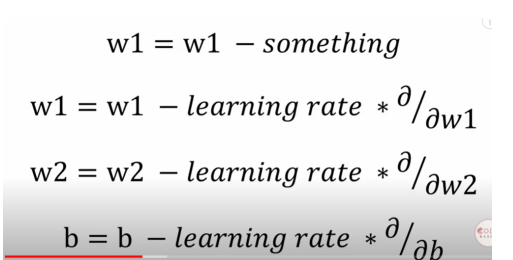 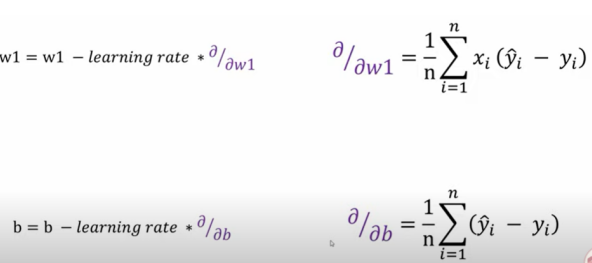

In [23]:
def gradient_descent(age, affordability, y_true, epochs, loss_thresold):
    w1 = w2 = 1
    bias = 0
    rate = 0.5  # Learning rate
    n = len(age)
    for i in range(epochs):
        weighted_sum = w1 * age + w2 * affordability + bias
        y_predicted = sigmoid_numpy(weighted_sum)
        loss = log_loss(y_true, y_predicted)
        
        # Derivatives
        w1d = (1/n)*np.dot(np.transpose(age),(y_predicted-y_true)) 
        w2d = (1/n)*np.dot(np.transpose(affordability),(y_predicted-y_true)) 

        #Apply GD formula
        bias_d = np.mean(y_predicted-y_true)
        w1 = w1 - rate * w1d
        w2 = w2 - rate * w2d
        bias = bias - rate * bias_d

        print (f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

        if loss<=loss_thresold:
            break

    return w1, w2, bias

In [24]:
gradient_descent(X_train_scaled['age'],X_train_scaled['affordibility'],y_train,1000, 0.4631)

Epoch:0, w1:0.974907633470177, w2:0.948348125394529, bias:-0.11341867736368583, loss:0.7113403233723417
Epoch:1, w1:0.9556229728273669, w2:0.9058873696677865, bias:-0.2122349122718517, loss:0.681264778737757
Epoch:2, w1:0.9416488476693794, w2:0.8719790823960313, bias:-0.2977578997796538, loss:0.6591474252715025
Epoch:3, w1:0.9323916996249162, w2:0.8457541517722915, bias:-0.3715094724003511, loss:0.6431523291301917
Epoch:4, w1:0.9272267472726993, w2:0.8262362885332687, bias:-0.43506643026891584, loss:0.6316873063379158
Epoch:5, w1:0.9255469396815343, w2:0.8124402814952774, bias:-0.48994490058938817, loss:0.623471707997592
Epoch:6, w1:0.9267936114129968, w2:0.8034375029757677, bias:-0.5375299543522853, loss:0.6175321183044205
Epoch:7, w1:0.93047170420295, w2:0.7983920007454487, bias:-0.5790424270894963, loss:0.6131591858705934
Epoch:8, w1:0.9361540784567942, w2:0.7965748796787705, bias:-0.6155315088627655, loss:0.6098518179750948
Epoch:9, w1:0.9434791243557357, w2:0.7973647616854131, bia

Epoch:111, w1:2.3480731153433556, w2:1.3167366432933292, bias:-1.7387452709042173, loss:0.5338989004550466
Epoch:112, w1:2.361344891223853, w2:1.318579538653317, bias:-1.7456292286588566, loss:0.5334433360772121
Epoch:113, w1:2.3745955651733888, w2:1.3203903898394993, bias:-1.752480052898938, loss:0.5329900530506113
Epoch:114, w1:2.387825068005961, w2:1.3221698206861112, bias:-1.759298182518741, loss:0.532539027907722
Epoch:115, w1:2.4010333328795768, w2:1.3239184427944621, bias:-1.7660840484474298, loss:0.5320902377642434
Epoch:116, w1:2.4142202952505927, w2:1.3256368557876617, bias:-1.772838073810153, loss:0.5316436602986057
Epoch:117, w1:2.427385892828985, w2:1.3273256475595065, bias:-1.7795606740855376, loss:0.5311992737322607
Epoch:118, w1:2.440530065534521, w2:1.328985394517677, bias:-1.7862522572596642, loss:0.5307570568107249
Epoch:119, w1:2.4536527554538115, w2:1.3306166618213877, bias:-1.7929132239766132, loss:0.5303169887853427
Epoch:120, w1:2.46675390679823, w2:1.3322200036

Epoch:210, w1:3.5551090594735104, w2:1.4088841920880264, bias:-2.3068826085968004, loss:0.49747959277116743
Epoch:211, w1:3.5662001550596885, w2:1.4093245362256548, bias:-2.3117883278953073, loss:0.4971841500153676
Epoch:212, w1:3.577269903447877, w2:1.4097605698133546, bias:-2.3166818905919, loss:0.4968899035764641
Epoch:213, w1:3.5883183376440364, w2:1.4101923859129344, bias:-2.321563382532884, loss:0.49659684764033973
Epoch:214, w1:3.5993454909464844, w2:1.4106200758158696, bias:-2.32643288833008, loss:0.49630497643310856
Epoch:215, w1:3.610351396938527, w2:1.4110437290759732, bias:-2.331290491382403, loss:0.49601428422049737
Epoch:216, w1:3.6213360894812157, w2:1.4114634335414504, bias:-2.3361362738970306, loss:0.4957247653072439
Epoch:217, w1:3.6322996027062318, w2:1.4118792753863514, bias:-2.3409703169101865, loss:0.49543641403651506
Epoch:218, w1:3.6432419710088983, w2:1.4122913391414305, bias:-2.345792700307536, loss:0.49514922478933926
Epoch:219, w1:3.6541632290413135, w2:1.41

Epoch:309, w1:4.555440516277136, w2:1.4412929450853456, bias:-2.7435830010515936, loss:0.4732431203448344
Epoch:310, w1:4.564603732304602, w2:1.4415698997254285, bias:-2.747567438235262, loss:0.473042716800984
Epoch:311, w1:4.573749495689255, w2:1.441846627196646, bias:-2.7515445246676515, loss:0.4728430721517801
Epoch:312, w1:4.58287784678835, w2:1.4421231396100629, bias:-2.7555142866949733, loss:0.4726441830446452
Epoch:313, w1:4.591988825911552, w2:1.4423994487964005, bias:-2.759476750423661, loss:0.4724460461436974
Epoch:314, w1:4.601082473319831, w2:1.4426755663113053, bias:-2.763431941723993, loss:0.47224865812965516
Epoch:315, w1:4.610158829224385, w2:1.4429515034405223, bias:-2.7673798862336514, loss:0.47205201569974303
Epoch:316, w1:4.619217933785582, w2:1.4432272712049754, bias:-2.7713206093612155, loss:0.47185611556759816
Epoch:317, w1:4.628259827111926, w2:1.4435028803657577, bias:-2.7752541362896017, loss:0.4716609544631776
Epoch:318, w1:4.63728454925905, w2:1.443778341429

(5.051047623653049, 1.4569794548473887, -2.9596534546250037)

In [26]:
#This is tensorflow coef and intercept

coef, intercept

(array([[5.0608673],
        [1.4086503]], dtype=float32),
 array([-2.913703], dtype=float32))

**This shows that in the end we were able to come up with same value of w1,w2 and bias using a plain python implementation of gradient descent function**